Estado inicial de los datos depurados:


,semana,fecha_semana,producto,precio_unit,promo,stock_inicio_sem,unidades_vendidas,stock_fin_sem,stockout_sem,lluvia_mm_sem,prox_feriado,competencia_precio,lead_time_dias,riesgo_quiebre_prox_sem,tasa_venta
0,1,2024-01-01,Paracetamol_500mg,1.25,0,103,21,82,0,24.6,1,1.24,5,0,0.203883
1,1,2024-01-01,Ibuprofeno_400mg,1.50,0,58,32,26,0,24.6,1,1.58,5,0,0.551724
2,1,2024-01-01,Antigripal,1.93,1,58,24,34,0,24.6,1,1.93,6,0,0.413793
3,1,2024-01-01,Vitaminas_C,2.97,0,62,22,40,0,24.6,1,3.05,4,0,0.354839
4,1,2024-01-01,Jarabe_Tos,3.59,0,89,15,74,0,24.6,1,3.74,9,0,0.168539
5,1,2024-01-01,Antiacido,2.10,1,59,16,43,0,24.6,1,2.23,4,0,0.271186
6,1,2024-01-01,Antihistaminico,2.68,0,96,11,85,0,24.6,1,2.80,3,0,0.114583
7,1,2024-01-01,Suero_Oral,0.91,1,85,23,62,0,24.6,1,0.94,6,0,0.270588
8,1,2024-01-01,Alcohol_Gel,1.83,0,95,11,84,0,24.6,1,1.87,4,0,0.115789
9,1,2024-01-01,Bloqueador_Solar,6.41,0,117,7,110,0,24.6,1,6.79,2,0,0.059829


producto
Ibuprofeno_400mg     3.85%
Paracetamol_500mg    3.85%
Alcohol_Gel          0.00%
Antiacido            0.00%
Antigripal           0.00%
Antihistaminico      0.00%
Bloqueador_Solar     0.00%
Jarabe_Tos           0.00%
Probiotico           0.00%
Repelente            0.00%
Name: %_semanas_sin_stock, dtype: object

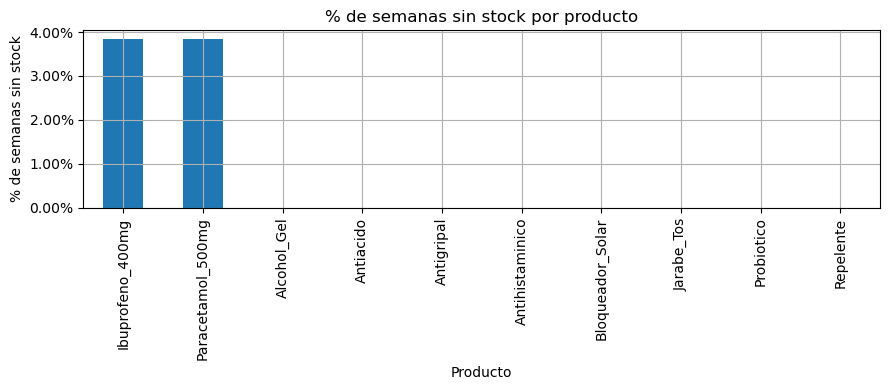

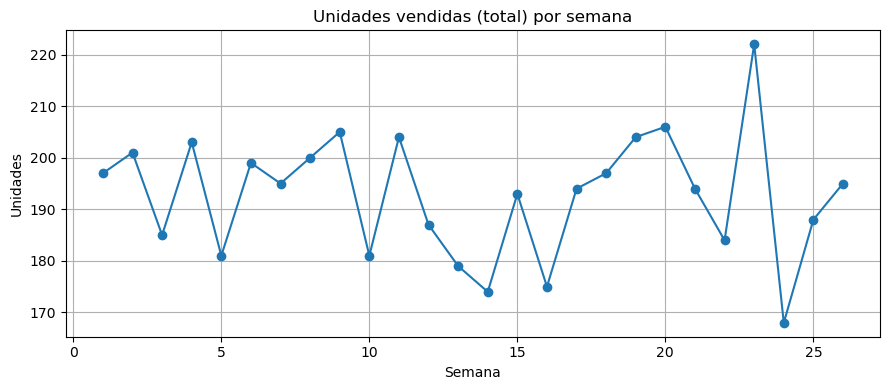

Pronóstico TOTAL para la semana 27: 191.4 unidades
Paracetamol_500mg: pronóstico para semana 27 = 41.1 unidades
Resumen de alertas (última semana): A=1 | B=1 | C=2


,producto,stock_fin_sem,forecast_next,cobertura_sem,tasa_venta,lead_time_dias,alerta_A,alerta_B,alerta_C,score_prioridad
0,Ibuprofeno_400mg,32,29.000000,1.103448,0.448276,5,1,1,1,0.903125
1,Probiotico,31,8.333333,3.720000,0.225000,3,0,0,1,0.384793
2,Paracetamol_500mg,61,35.666667,1.710280,0.445455,6,0,0,0,0.791091
3,Suero_Oral,71,15.333333,4.630435,0.183908,6,0,0,0,0.490033
4,Jarabe_Tos,70,13.000000,5.384615,0.125000,6,0,0,0,0.448626
5,Antigripal,76,16.333333,4.653061,0.191489,4,0,0,0,0.392890
6,Vitaminas_C,50,14.333333,3.488372,0.230769,2,0,0,0,0.346292
7,Repelente,61,5.666667,10.764706,0.102941,5,0,0,0,0.342376
8,Antiacido,59,12.666667,4.657895,0.180556,3,0,0,0,0.337900
9,Alcohol_Gel,89,12.666667,7.026316,0.118812,2,0,0,0,0.224169


In [8]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# Configuración visual de los gráficos
plt.rcParams["figure.figsize"] = (9, 4) 
plt.rcParams["axes.grid"] = True 

# Definir el nombre del archivo exacto del ejercicio
CSV = "ejercicio_fases_analitica_farmacia.csv" 

# Carga de la base de datos
df = pd.read_csv(CSV)  

# --- PREPARACIÓN DE DATOS ---
# Convertir columna de fecha a formato datetime 
df["fecha_semana"] = pd.to_datetime(df["fecha_semana"], errors="coerce") 

# Asegurar que la semana sea un valor entero 
df["semana"] = df["semana"].astype(int) 

# Crear la métrica 'tasa_venta' (proporción de stock vendido) 
df["tasa_venta"] = df["unidades_vendidas"] / df["stock_inicio_sem"] 

# --- VISTA RÁPIDA (Como en el documento) ---
# Muestra las primeras 5 filas para verificar la carga 
print("Estado inicial de los datos depurados:")
display(df.head(10))

import matplotlib.ticker as mtick 

# --- Top productos por semanas sin stock --- 
# Renombramos para mayor claridad en el análisis
df = df.rename(columns={"stockout_sem": "semana_sin_stock"}) 

top_sin_stock = (  
    df.groupby("producto")["semana_sin_stock"] 
    .mean()                           # proporción de semanas sin stock 
    .sort_values(ascending=False) 
    .head(10) 
) 

# Mostrar la tabla de porcentajes
display(top_sin_stock.rename("%_semanas_sin_stock").map(lambda x: f"{x*100:.2f}%")) 

# Gráfico de barras de stockouts
ax = top_sin_stock.plot(kind="bar") 
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) 
plt.title("% de semanas sin stock por producto") 
plt.ylabel("% de semanas sin stock") 
plt.xlabel("Producto") 
plt.tight_layout() 
plt.show() 

# --- Tendencia de unidades vendidas totales --- 
serie_total = df.groupby("semana")["unidades_vendidas"].sum() 
ax = serie_total.plot(marker="o") 
plt.title("Unidades vendidas (total) por semana") 
plt.ylabel("Unidades") 
plt.xlabel("Semana") 
plt.tight_layout() 
plt.show()


# === PREDICTIVA: Tendencia lineal === 
import numpy as np 

# Pronóstico Total por semana  
serie = df.groupby("semana")["unidades_vendidas"].sum().reset_index() 
X = serie["semana"].to_numpy().reshape(-1,1) 
y = serie["unidades_vendidas"].to_numpy() 

Xd = np.hstack([X, np.ones_like(X)]) # Matriz de diseño
a, b = (np.linalg.pinv(Xd.T @ Xd) @ (Xd.T @ y)).tolist() # Mínimos cuadrados

next_week = int(serie["semana"].max() + 1) 
y_next = a * next_week + b 

print(f"Pronóstico TOTAL para la semana {next_week}: {y_next:.1f} unidades") 

# Pronóstico para un producto específico
prod = "Paracetamol_500mg" 
s_prod = (df[df["producto"] == prod].groupby("semana")["unidades_vendidas"].sum().reset_index())  

if len(s_prod) >= 3: 
    Xp = s_prod["semana"].to_numpy().reshape(-1, 1) 
    yp = s_prod["unidades_vendidas"].to_numpy() 
    Xpd = np.hstack([Xp, np.ones_like(Xp)]) 
    ap, bp = (np.linalg.pinv(Xpd.T @ Xpd) @ (Xpd.T @ yp)).tolist() 
    y_next_prod = ap * next_week + bp 
    print(f"{prod}: pronóstico para semana {next_week} = {y_next_prod:.1f} unidades")


# === PRESCRIPTIVA: Alertas de reorden === 
last_w = int(df["semana"].max()) 
base = df.loc[df["semana"] == last_w].copy() 

# Pronóstico simple media de últimas 3 semanas
agg = df.groupby(["producto", "semana"], as_index=False)["unidades_vendidas"].sum() 
hist3 = (agg.sort_values(["producto", "semana"]).groupby("producto", group_keys=False).tail(3)) 
prom3 = (hist3.groupby("producto", as_index=False)["unidades_vendidas"].mean().rename(columns={"unidades_vendidas": "forecast_next"}))  

base = base.merge(prom3, on="producto", how="left")  
base["forecast_next"] = base["forecast_next"].fillna(base["unidades_vendidas"]).clip(lower=1) 

# Cobertura en semanas 
base["cobertura_sem"] = (base["stock_fin_sem"] / base["forecast_next"]).replace([np.inf, -np.inf], np.nan).fillna(999.0) 

# Percentiles históricos
p25_stock = df.groupby("producto")["stock_fin_sem"].quantile(0.25).rename("p25_stock") 
p75_tasa = df.groupby("producto")["tasa_venta"].quantile(0.75).rename("p75_tasa") 
base = base.merge(p25_stock, on="producto", how="left").merge(p75_tasa, on="producto", how="left")  

# Lógicas de Alerta
UMBRAL_COBERTURA_A = 1.5; UMBRAL_STOCK_BAJO = 30; UMBRAL_LEADTIME_A = 4
base["alerta_A"] = ((base["cobertura_sem"] < UMBRAL_COBERTURA_A) | (base["stock_fin_sem"] <= UMBRAL_STOCK_BAJO) | ((base["tasa_venta"] > 0.50) & (base["lead_time_dias"] >= UMBRAL_LEADTIME_A))).astype(int)

UMBRAL_COBERTURA_B = 1.2; UMBRAL_LEADTIME_B = 5 
base["alerta_B"] = ((base["cobertura_sem"] < UMBRAL_COBERTURA_B) & (base["lead_time_dias"] >= UMBRAL_LEADTIME_B)).astype(int)

base["alerta_C"] = ((base["stock_fin_sem"] <= base["p25_stock"].fillna(base["stock_fin_sem"].min())) | ((base["tasa_venta"] >= base["p75_tasa"].fillna(base["tasa_venta"].median())) & (base["lead_time_dias"] >= 5))).astype(int)

# Score de prioridad y tabla final
inv_cov = 1.0 / np.maximum(base["cobertura_sem"], 0.1) 
base["score_prioridad"] = 0.5 * inv_cov + 0.3 * (base["lead_time_dias"] / base["lead_time_dias"].max()) + 0.2 * (base["tasa_venta"] / base["tasa_venta"].max()) 

cols = ["producto", "stock_fin_sem", "forecast_next", "cobertura_sem", "tasa_venta", "lead_time_dias", "alerta_A", "alerta_B", "alerta_C", "score_prioridad"] 
tabla_alertas = base[cols].sort_values(["alerta_B", "alerta_A", "alerta_C", "score_prioridad"], ascending=[False, False, False, False]).reset_index(drop=True) 

print(f"Resumen de alertas (última semana): A={int(base['alerta_A'].sum())} | B={int(base['alerta_B'].sum())} | C={int(base['alerta_C'].sum())}") 
display(tabla_alertas.head(15))